In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pickle

#dataset load krwane mai help karegi
from datasets import load_dataset

In [2]:
emotion_dataset = load_dataset('dair-ai/emotion')

train_text = emotion_dataset['train']['text']
train_label = emotion_dataset['train']['label']

# IMPROVED: load the real validation split instead of reusing test as validation
val_text = emotion_dataset['validation']['text']
val_label = emotion_dataset['validation']['label']

test_text = emotion_dataset['test']['text']
test_label = emotion_dataset['test']['label']

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  129kB            

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [3]:
label_names = emotion_dataset['train'].features['label'].names

In [4]:
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [5]:
df_train = pd.DataFrame({'text': train_text, 'label': [label_names[i] for i in train_label]})
df_val   = pd.DataFrame({'text': val_text,   'label': [label_names[i] for i in val_label]})
df_test  = pd.DataFrame({'text': test_text,  'label': [label_names[i] for i in test_label]})

In [6]:
df_train.isnull().sum()

,0
text,0
label,0


In [7]:
df_train['label'].value_counts()

,count
label,
joy,5362
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


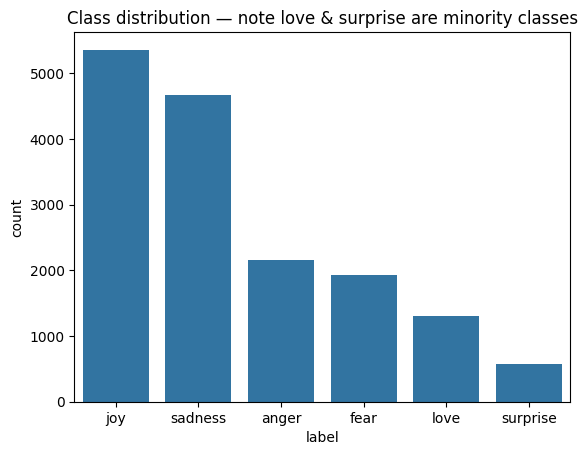

In [8]:
sns.countplot(x='label', data=df_train, order=df_train['label'].value_counts().index)
plt.title('Class distribution — note love & surprise are minority classes')
plt.show()

In [9]:
df_train

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


In [10]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 15000   # IMPROVED: was 10000
max_len = 50

tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')  # IMPROVED: was oov_token=''
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
val_sequence   = tokenizer.texts_to_sequences(df_val['text'])    # IMPROVED: tokenize validation split
test_sequence  = tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence = pad_sequences(train_sequence, maxlen=max_len, padding='post', truncating='post')
padded_val_sequence   = pad_sequences(val_sequence,   maxlen=max_len, padding='post', truncating='post')
padded_test_sequence  = pad_sequences(test_sequence,  maxlen=max_len, padding='post', truncating='post')

train_labels = np.array(train_label)
val_labels   = np.array(val_label)
test_labels  = np.array(test_label)

num_classes = len(np.unique(train_labels))

print(f'Vocabulary size seen: {len(tokenizer.word_index)}')
print(f'Vocabulary size used (num_words cap): {max_words}')
print(f'Max sentence length: {padded_train_sequence.shape[1]}')

Vocabulary size seen: 15213
Vocabulary size used (num_words cap): 15000
Max sentence length: 50


In [11]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weight_dict = dict(enumerate(class_weights))
class_weight_dict

{0: np.float64(0.5715102157451064),
 1: np.float64(0.49732686808404825),
 2: np.float64(2.044989775051125),
 3: np.float64(1.2351397251814111),
 4: np.float64(1.3766993632765445),
 5: np.float64(4.662004662004662)}

In [12]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

os.makedirs('Artifacts', exist_ok=True)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# IMPROVED: new callbacks
checkpoint = ModelCheckpoint(
    filepath='Artifacts/best_model.keras',
    monitor='val_loss',
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, GRU, Dropout, SpatialDropout1D, Dense

BiGRU = Sequential([
    Embedding(input_dim=max_words, output_dim=300, mask_zero=True),        # FIXED: mask_zero=True
                                                                             # ignores padding timesteps instead
                                                                             # of feeding zeros through the GRU —
                                                                             # this is what was breaking short inputs
    SpatialDropout1D(0.3),
    Bidirectional(GRU(128, return_sequences=True, recurrent_dropout=0.2)),
    Dropout(0.5),
    Bidirectional(GRU(64, recurrent_dropout=0.2)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
BiGRU.build(input_shape=(None, max_len))
BiGRU.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 300)        │     4,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 50, 300)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 50, 256)        │       330,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       123,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,954,662 (18.90 MB)

 Trainable params: 4,954,662 (18.90 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_val_sequence, val_labels),
    epochs=30,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping, checkpoint, reduce_lr]
)

Epoch 1/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 393s 746ms/step - accuracy: 0.5733 - loss: 1.0434 - val_accuracy: 0.8940 - val_loss: 0.3350 - learning_rate: 0.0010
Epoch 2/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 363s 710ms/step - accuracy: 0.9196 - loss: 0.2332 - val_accuracy: 0.9170 - val_loss: 0.2421 - learning_rate: 0.0010
Epoch 3/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 331s 662ms/step - accuracy: 0.9501 - loss: 0.1256 - val_accuracy: 0.9245 - val_loss: 0.2371 - learning_rate: 0.0010
Epoch 4/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 391s 679ms/step - accuracy: 0.9644 - loss: 0.0894 - val_accuracy: 0.9220 - val_loss: 0.2357 - learning_rate: 0.0010
Epoch 5/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 345s 690ms/step - accuracy: 0.9739 - loss: 0.0677 - val_accuracy: 0.9185 - val_loss: 0.2603 - learning_rate: 0.0010
Epoch 6/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 322s 645ms/step - accuracy: 0.9786 - loss: 0.0536 - val_accuracy: 0.9165 - val_loss: 0.2872 - learning_rate: 0.0010
Epoch 7/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 340s 679ms/step - accura

In [15]:
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence, test_labels)
print(f'BiGRU Test Loss: {BiGRU_loss}')
print(f'BiGRU Test Accuracy: {BiGRU_accuracy}')

63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - accuracy: 0.9155 - loss: 0.2454
BiGRU Test Loss: 0.24535322189331055
BiGRU Test Accuracy: 0.9154999852180481


63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 114ms/step
              precision    recall  f1-score   support

     sadness       0.98      0.94      0.96       581
         joy       0.96      0.91      0.94       695
        love       0.75      0.94      0.83       159
       anger       0.91      0.90      0.90       275
        fear       0.84      0.89      0.87       224
    surprise       0.70      0.82      0.76        66

    accuracy                           0.92      2000
   macro avg       0.86      0.90      0.88      2000
weighted avg       0.92      0.92      0.92      2000



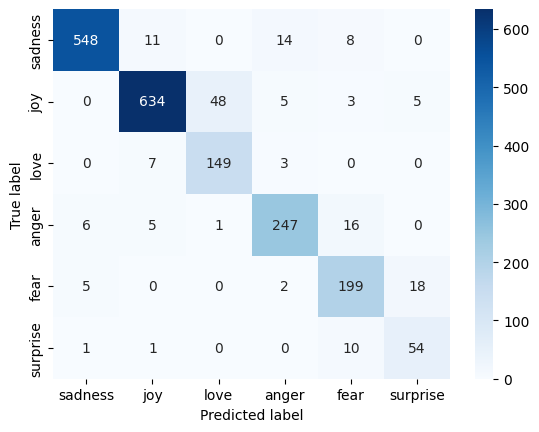

In [16]:
from sklearn.metrics import confusion_matrix, classification_report

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequence), axis=1)

print(classification_report(test_labels, BiGRU_predictions, target_names=label_names))

sns.heatmap(confusion_matrix(test_labels, BiGRU_predictions), annot=True, fmt='d',
            cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [17]:
def predict_emotion(text, model=BiGRU, tok=tokenizer, maxlen=max_len, labels=label_names, return_probs=False):
    seq = tok.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=maxlen, padding='post', truncating='post')
    probs = model.predict(padded, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    if return_probs:
        return labels[pred_idx], dict(zip(labels, probs.tolist()))
    return labels[pred_idx]

sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!",
    "I am happy",
    "I love my girlfriend",
]

for t in sample_texts:
    label, probs = predict_emotion(t, return_probs=True)
    top3 = sorted(probs.items(), key=lambda x: -x[1])[:3]
    print(f'Text: {t}')
    print(f'  Predicted: {label}')
    print(f'  Top 3: {top3}')
    print()

Text: I can't believe how happy I am right now, this is amazing!
  Predicted: surprise
  Top 3: [('surprise', 0.7571830153465271), ('joy', 0.1888757199048996), ('love', 0.03613387793302536)]

Text: I feel so alone and hopeless today.
  Predicted: sadness
  Top 3: [('sadness', 0.9998944997787476), ('fear', 7.279424607986584e-05), ('joy', 1.6975918697426096e-05)]

Text: I am furious that they cancelled the trip at the last minute.
  Predicted: anger
  Top 3: [('anger', 0.9930117726325989), ('joy', 0.0043485271744430065), ('fear', 0.0013324676547199488)]

Text: I feel terrified when walking down dark alleyways alone.
  Predicted: fear
  Top 3: [('fear', 0.9998366832733154), ('sadness', 5.554610470426269e-05), ('joy', 3.9819897210691124e-05)]

Text: I was shocked and completely surprised by the unexpected gift!
  Predicted: surprise
  Top 3: [('surprise', 0.9964632391929626), ('joy', 0.0019171625608578324), ('fear', 0.0010919449850916862)]

Text: I am happy
  Predicted: joy
  Top 3: [('joy

In [18]:
model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True)

BiGRU.save(os.path.join(model_dir, 'BiGRU_model.keras'))

with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as f:
    pickle.dump(tokenizer, f)

# IMPROVED: persist config needed for correct inference elsewhere
with open(os.path.join(model_dir, 'config.pkl'), 'wb') as f:
    pickle.dump({'max_len': max_len, 'label_names': label_names}, f)

print('Saved model, tokenizer, and config to', model_dir)

Saved model, tokenizer, and config to Artifacts


In [19]:
## If you deploy this elsewhere (Flask app, API, etc.)

# Load all three artifacts together and reuse the same `predict_emotion` logic — never re-instantiate a fresh `Tokenizer()`:
import pickle
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

model = load_model('Artifacts/BiGRU_model.keras')
with open('Artifacts/tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)
with open('Artifacts/config.pkl', 'rb') as f:
    config = pickle.load(f)

def predict_emotion(text):
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=config['max_len'], padding='post', truncating='post')
    probs = model.predict(padded, verbose=0)[0]
    return config['label_names'][probs.argmax()]